# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_CREDIT_RECORD= Path("..") / "data" / "raw" / "credit_record.csv"          # PREENCHER: nome do arquivo
RAW_APPLICATION_RECORD= Path("..") / "data" / "raw" / "application_record.csv"     # PREENCHER: nome do arquivo
PROCESSED = Path("..") / "data" / "processed"
TARGET = "target"                                            # PREENCHER: variável alvo

pd.set_option("display.max_columns", None)

In [2]:
# Carregando as cópias das bases de dados originais
df_credit_record = pd.read_csv(RAW_CREDIT_RECORD)
df_application_record = pd.read_csv(RAW_APPLICATION_RECORD)

## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [3]:
# Verificando as dimensões iniciais das bases
print("Dimensões de df_application_record:", df_application_record.shape)
print("Dimensões de df_credit_record:", df_credit_record.shape)



Dimensões de df_application_record: (438557, 18)
Dimensões de df_credit_record: (1048575, 3)


In [4]:
# Informações sobre tipos de dados e contagem de nulos
print("\n--- Informações Cadastrais (df_application_record) ---")
df_application_record.info()




--- Informações Cadastrais (df_application_record) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE  

In [5]:
print("\n--- Informações de Crédito Monthly (df_credit_record) ---")
df_credit_record.info()




--- Informações de Crédito Monthly (df_credit_record) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [6]:
df_application_record.isnull().sum()# Verificando se tem dados nulos

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

### Dicionário de Dados do df_application_record
|  **Nome da Coluna**      | Tipo de Dado | Descrição / Significado |  
| :---: | :---: | :---: |
| **ID**                  | int64   | dentificador único do cliente. |  
| **CODE_GENDER**         | object  | Gênero do cliente (Ex: M/F). |  
| **FLAG_OWN_CAR**        | object  | Indica se o cliente possui carro próprio (Y/N). |  
| **FLAG_OWN_REALTY**     | object  | Indica se o cliente possui imóvel próprio (Y/N). |  
| **CNT_CHILDREN**        | int64   | Quantidade de filhos do cliente. |  
| **AMT_INCOME_TOTAL**    | float64 | Rendimento anual total do cliente. |  
| **NAME_INCOME_TYPE**    | object  | Tipo de renda (Ex: Assalariado, Pensionista, Estudante). |  
| **NAME_EDUCATION_TYPE** | object  | Grau de escolaridade (Ex: Ensino Médio, Ensino Superior). |  
| **NAME_FAMILY_STATUS**  | object  | Estado civil (Ex: Casado, Solteiro, Divorciado). |  
| **NAME_HOUSING_TYPE**   | object  | Tipo de moradia (Ex: Casa própria, Apartamento alugado). |  
| **DAYS_BIRTH**          | int64   | Idade em dias (contados regressivamente a partir de hoje. Ex:  -12000). |  
| **DAYS_EMPLOYED**       | int64   | Tempo de emprego em dias (regressivo. Se positivo, significa desempregado). |  
| **FLAG_MOBIL**          | int64   | Indica se informou telefone celular (1 = Sim, 0 = Não). |  
| **FLAG_WORK_PHONE**     | int64   | Indica se informou telefone comercial (1 = Sim, 0 = Não). |  
| **FLAG_PHONE**          | int64   | Indica se informou telefone fixo residencial (1 = Sim, 0 = Não). |  
| **FLAG_EMAIL**          | int64   | Indica se informou e-mail (1 = Sim, 0 = Não). |  
| **OCCUPATION_TYPE**     | object  | Profissão/Ocupação (Contém dados faltantes). |  
| **CNT_FAM_MEMBERS**     | float64 | Quantidade de membros na família. |  

### Dicionário de Dados do df_credit_record
|  **Nome da Coluna**      | Tipo de Dado | Descrição / Significado |  
| :---: | :---: | :---: |
| **ID**                  | int64   | Identificador único do cliente ou da conta de crédito.5001711, 5001712| 
| **MONTHS_BALANCE**      | int64   | Mês de referência dos dados em relação ao mês atual.0 (mês atual), -1 (1 mês atrás), -2 (2 meses atrás)|
| **STATUS**              | object  | Situação de pagamento (0: 1-29 dias; 1: 30-59; 2: 60-89; 3: 90-119; 4: 120-149; 5: >150 dias; C: pago; X: sem empréstimo).|

## 2. Distribuição das variáveis

### 2.1 ANÁLISE UNIVARIADA 

### Análise da Renda Anual Total (AMT_INCOME_TOTAL)

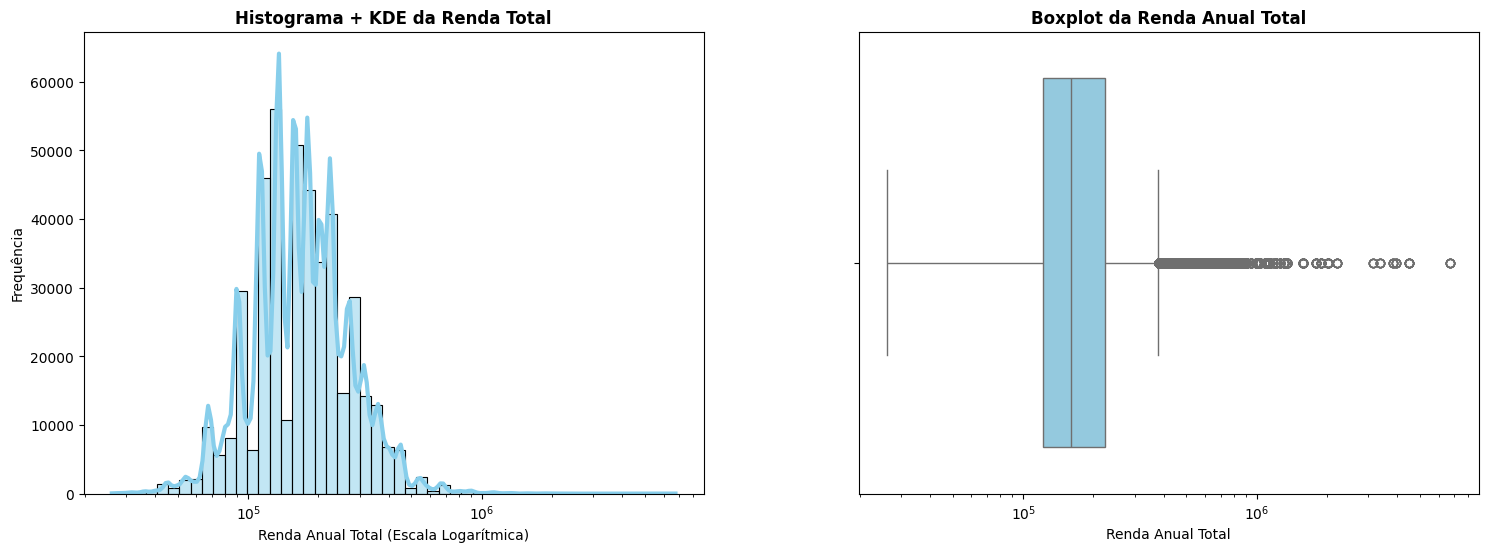

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.25)

# Gráfico 1: Histograma + KDE (Escala Logarítmica)
sns.histplot(
    data=df_application_record,
    x="AMT_INCOME_TOTAL",
    kde=True,
    color="skyblue",
    bins=50,
    log_scale=True,
    line_kws={'linewidth': 3, 'color': 'darkblue'},
    ax=axes[0]
)
axes[0].set_title("Histograma + KDE da Renda Total", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Renda Anual Total (Escala Logarítmica)")
axes[0].set_ylabel("Frequência")

# Gráfico 2: Boxplot (Escala Logarítmica)
sns.boxplot(
    data=df_application_record,
    x="AMT_INCOME_TOTAL",
    color="skyblue",
    ax=axes[1]
)
axes[1].set_title('Boxplot da Renda Anual Total', fontsize=12, fontweight='bold')
axes[1].set_xlabel("Renda Anual Total")
axes[1].set_xscale('log')

plt.show()

Perfil do Público Alvo: A base de clientes exibe uma forte concentração na classe 
média alta, com a mediana da renda anual situada próxima a 160.000 unidades 
monetárias. Sob a perspectiva estatística, a distribuição da renda apresenta uma 
assimetria acentuada à direita, mas assume um formato de sino simétrico e bem 
definido quando convertida para a escala logarítmica (Log-Normal). Isso indica 
que uma transformação matemática (como log1p) suavizará perfeitamente o impacto 
de outliers de alta renda (valores acima de 400.000), tornando-a altamente aderente 
para algoritmos preditivos baseados em distância ou modelos lineares.


### Análise da Idade dos Clientes (DAYS_BIRTH convertido para Idade)

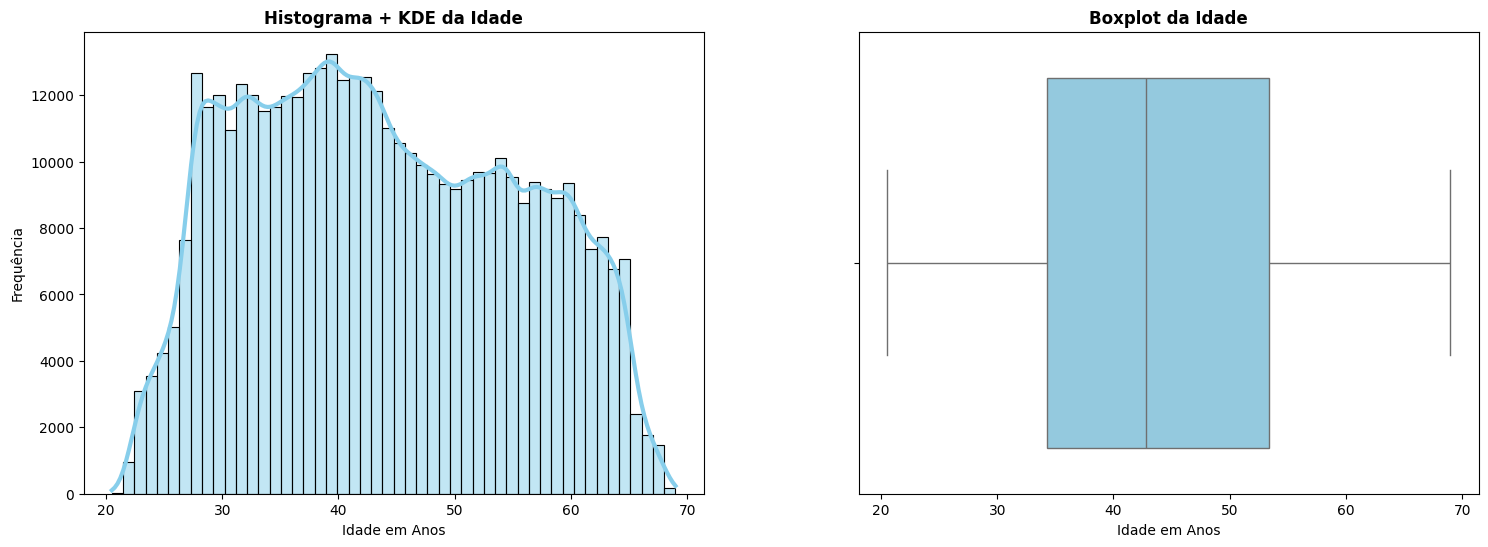

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.25)

# Conversão temporária de dias negativos para idade positiva em anos
idade_anos = -df_application_record['DAYS_BIRTH'] / 365.25

# Gráfico 1: Histograma + KDE
sns.histplot(
    x=idade_anos,
    kde=True,
    color="skyblue",
    bins=50,
    line_kws={'linewidth': 3, 'color': 'darkblue'},
    ax=axes[0]
)
axes[0].set_title("Histograma + KDE da Idade", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Idade em Anos")
axes[0].set_ylabel("Frequência")

# Gráfico 2: Boxplot
sns.boxplot(
    x=idade_anos,
    color="skyblue",
    ax=axes[1]
)
axes[1].set_title('Boxplot da Idade', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Idade em Anos')

plt.show()

Distribuição Etária Equilibrada: A análise da idade indica uma carteira de 
clientes madura e consolidada, com comportamento estatisticamente estável. A 
mediana etária é de 43 anos, e o grosso da população cadastrada (o intervalo 
interquartílico no Boxplot) distribui-se de maneira uniforme entre 34 e 53 anos. 
Trata-se de um público em plena fase de estabilidade financeira e atividade 
econômica ativa, o que reduz incertezas no perfil cadastral. Adicionalmente, 
a distribuição não apresenta assimetrias severas e está totalmente livre de 
outliers (anomalias), dispensando remoções ou tratamentos extremos nesta coluna.

### Análise do Tempo de Emprego (DAYS_EMPLOYED convertido para Anos)

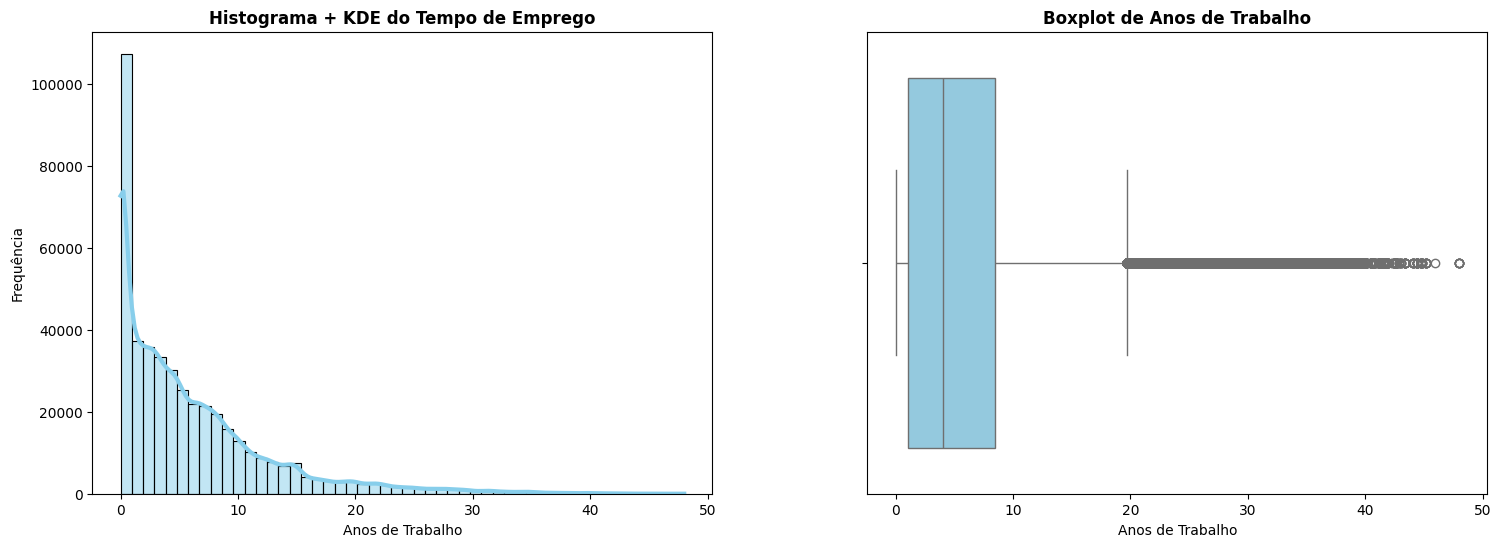

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.25)

# Tratamento temporário isolando o valor anômalo (365243) para cálculo real de anos
anos_trabalho = df_application_record["DAYS_EMPLOYED"].apply(lambda x: -x / 365.25 if x < 0 else 0)

# Gráfico 1: Histograma + KDE
sns.histplot(
    x=anos_trabalho,
    kde=True,
    color="skyblue",
    bins=50,
    line_kws={'linewidth': 3, 'color': 'darkblue'},
    ax=axes[0]
)
axes[0].set_title("Histograma + KDE do Tempo de Emprego", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Anos de Trabalho")
axes[0].set_ylabel("Frequência")

# Gráfico 2: Boxplot
sns.boxplot(
    x=anos_trabalho,
    color="skyblue",
    ax=axes[1]
)
axes[1].set_title('Boxplot de Anos de Trabalho', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Anos de Trabalho')

plt.show()


Dinâmica Profissional e Estabilidade: O tempo de serviço apresenta um pico 
expressivo na marca de 0 anos, impulsionado pela presença massiva do valor 
técnico original '365243', que representa indivíduos sem vínculo formal ativo 
(como aposentados e pensionistas). Entre a parcela economicamente activa, nota-se 
um perfil de transição ou menor estabilidade no emprego atual, visto que a 
maioria absoluta possui menos de 7 anos de casa. Contudo, o boxplot revela uma 
cauda longa com outliers legítimos de clientes que mantêm alta estabilidade corporativa 
(mais de 20 anos na mesma função), um fator altamente favorável à concessão de crédito.


### Análise da Estrutura Familiar (Filhos e Membros)

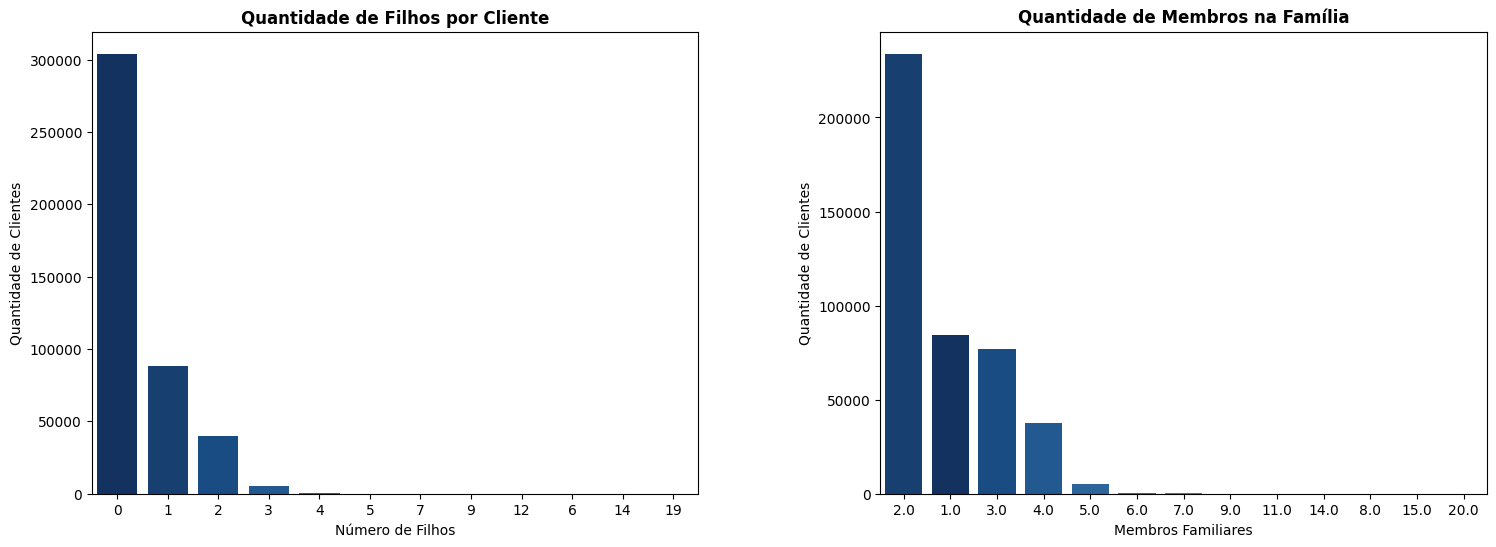

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.3)

# Gráfico 1: Quantidade de Filhos (CORRIGIDO: adicionado hue e legend=False)
sns.countplot(
    data=df_application_record,
    x="CNT_CHILDREN",
    hue="CNT_CHILDREN",
    palette="Blues_r",
    legend=False,
    ax=axes[0],
    order=df_application_record["CNT_CHILDREN"].value_counts().index
)

axes[0].set_title("Quantidade de Filhos por Cliente", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Número de Filhos")
axes[0].set_ylabel("Quantidade de Clientes")

# Gráfico 2: Membros na Família (CORRIGIDO: adicionado hue e legend=False)
sns.countplot(
    data=df_application_record,
    x="CNT_FAM_MEMBERS",
    hue="CNT_FAM_MEMBERS",
    palette="Blues_r",
    legend=False,
    ax=axes[1],
    order=df_application_record["CNT_FAM_MEMBERS"].value_counts().index
)

axes[1].set_title("Quantidade de Membros na Família", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Membros Familiares")
axes[1].set_ylabel("Quantidade de Clientes")

plt.show()


Padrão de Núcleo Familiar Reduzido: Ambas as distribuições categóricas discretas demonstram que a grande maioria da base de proponentes é caracterizada por arranjos familiares enxutos. A moda absoluta para a coluna de filhos é zero, indicando quea maior parte dos clientes não possui dependentes diretos. Consequentemente, o tamanho total das famílias concentra-se predominantemente em núcleos formados por 1 ou 2 indivíduos (pessoas solteiras ou casais sem filhos). Esse padrão sugere menor comprometimento da renda com despesas familiares fixas. Do ponto de vista técnico, a quase perfeita redundância visual entre os gráficos alerta para um risco elevado de multicolinearidade, exigindo atenção ou descarte de uma das features no pipeline.

### Análise Demográfica de Meio de Contato e Tempo Histórico

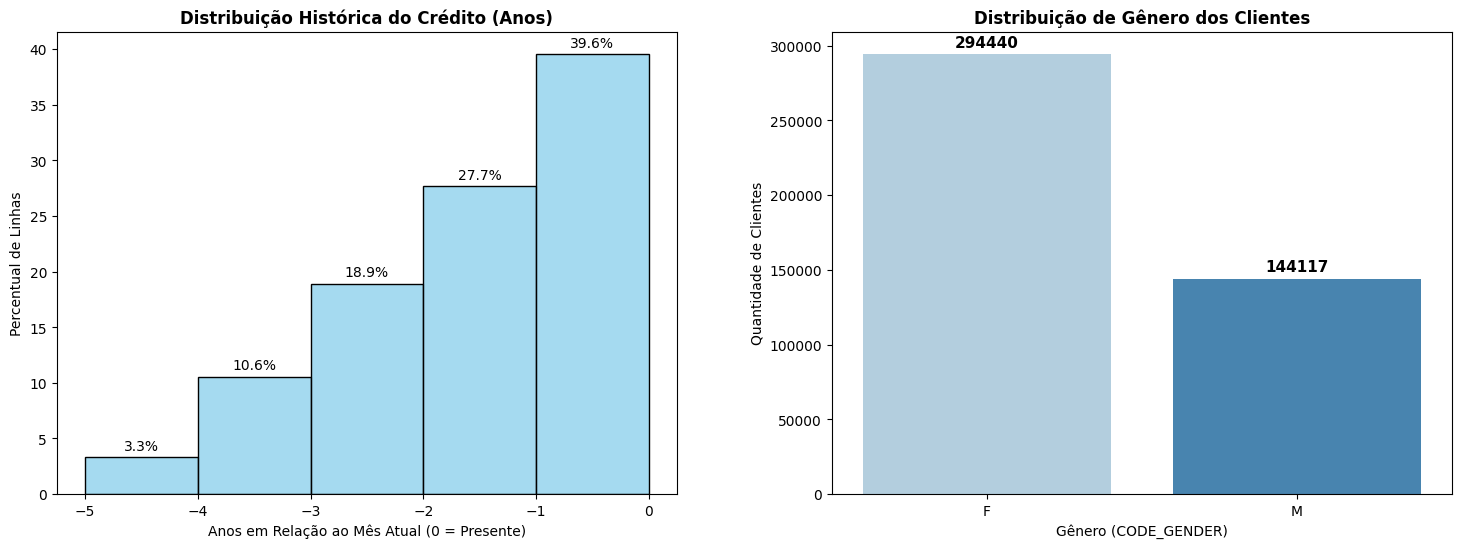

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.25)

# Gráfico 1: Histograma de MONTHS_BALANCE em Anos
ax1 = sns.histplot(
    data=df_credit_record,
    x=df_credit_record["MONTHS_BALANCE"] / 12,
    stat="percent",
    color="skyblue",
    edgecolor="black",
    bins=5, ax=axes[0]
)
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontsize=10, fmt="%.1f%%")
axes[0].set_title("Distribuição Histórica do Crédito (Anos)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Anos em Relação ao Mês Atual (0 = Presente)")
axes[0].set_ylabel("Percentual de Linhas")

# Gráfico 2: Volumetria de Gênero (CORRIGIDO: adicionado hue e legend=False)
ax2 = sns.countplot(
    data=df_application_record,
    x="CODE_GENDER",
    hue="CODE_GENDER",
    palette="Blues_r",
    legend=False,
    ax=axes[1],
    order=df_application_record["CODE_GENDER"].value_counts().index
)
for container in ax2.containers:
    ax2.bar_label(container, padding=3, fontsize=11, fontweight="bold", fmt='%d')
axes[1].set_title("Distribuição de Gênero dos Clientes", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Gênero (CODE_GENDER)")
axes[1].set_ylabel("Quantidade de Clientes")

plt.show()


Distribuição Histórica e Representatividade: A janela histórica de comportamento de crédito revela que o maior volume de registros está nos dados mais recentes (com **39.6%** acumulados no primeiro ano em relação ao presente), decaindo de forma constante até atingir os dados de 5 anos atrás (**3.3%**). Isso aponta para um crescimento robusto de faturamento de dados recentes. Do lado demográfico, há um forte desbalanceamento,com o público feminino (*F*) representando cerca de **67%** dos cadastros. No entanto, por conter mais de **140 mil** registros na classe minoritária (*M*), ambos os gêneros possuem volumetria suficiente para que os modelos aprendam sem problemas de sub-amostragem.

#### Exploração do Histórico de Crédito

Para que a nossa Análise Exploratória de Dados avalie o potencial preditivo das variáveis cadastrais, precisamos primeiro entender como o comportamento de risco do cliente é extraído do histórico mensal de pagamentos (`df_credit_record`). 

Antes de cruzar o cadastro com o risco, avaliaremos a distribuição de frequência e a volumetria da variável `STATUS` original. Essa análise servirá de embasamento estatístico e de negócio para definirmos o limiar de inadimplência (Mau Pagador).


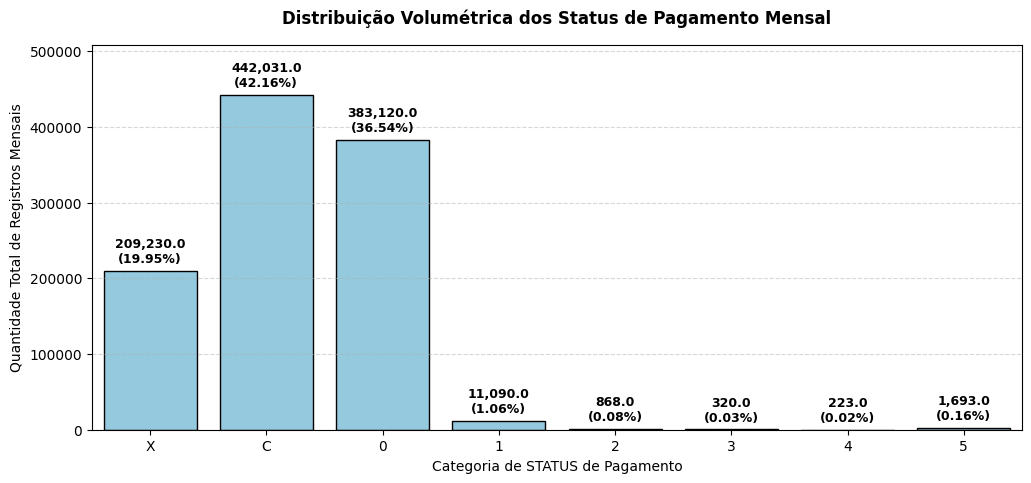

In [12]:
# Criando uma cópia isolada da base de créditos para análise de segurança
df_credit_clean = df_credit_record.copy()

# 1. Calculando a volumetria bruta e percentual de cada STATUS no histórico mensal
status_counts = df_credit_clean["STATUS"].value_counts()
status_pct = df_credit_clean["STATUS"].value_counts(normalize=True) * 100

# Ordenando as categorias de forma lógica: X (sem empréstimo), C (pago), 0 (1-29 dias), 1 (30-59 dias)...
ordem_status = [s for s in ["X", "C", "0", "1", "2", "3", "4", "5"] if s in status_counts.index]
status_counts = status_counts.reindex(ordem_status)
status_pct = status_pct.reindex(ordem_status)

# 2. Plotagem do gráfico de barras para a distribuição de STATUS
plt.figure(figsize=(12, 5))
ax = sns.barplot(x=status_counts.index, y=status_counts.values, color="skyblue", edgecolor="black")

for i, p in enumerate(ax.patches):
    height = p.get_height()
    pct = status_pct.values[i]
    ax.annotate(f"{height:,}\n({pct:.2f}%)", (p.get_x() + p.get_width() / 2., height),
                ha="center", va="bottom", fontsize=9, weight="bold", xytext=(0, 4), textcoords="offset points")

plt.title("Distribuição Volumétrica dos Status de Pagamento Mensal", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Categoria de STATUS de Pagamento")
plt.ylabel("Quantidade Total de Registros Mensais")
plt.ylim(0, max(status_counts.values) * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


**Embasamento estatístico e Justificativa de Negócio:**

A distribuição histórica mostra que a grande maioria dos registros mensais representa um comportamento saudável de crédito, dividida entre contas pagas em dia (categoria **C**) e meses sem uso da linha (categoria **X**). A categoria **0** representa atrasos leves (1 a 29 dias), comuns em operações de varejo e de baixo risco estrutural.

A partir do status **1** (atraso de 30 a 59 dias) até o status **5** (atraso crítico superior a 150 dias), as barras se tornam eventos extremamente raros e marginais na escala. A transição do status **0** para o **1** marca a quebra de confiança e o início da inadimplência grave (*Default*). 

Portanto, definiremos estatisticamente como **Mau Pagador** o cliente que atingiu os status de 1 a 5 em qualquer momento do seu histórico, e como **Bom Pagador** os demais. Abaixo, faremos o cruzamento (Análise Bivariada) das variáveis numéricas de Renda e Idade contra essa candidata a variavel *TARGET* para validar o seu potencial discriminatório.


### 2.2 ANÁLISE BIVARIADA (RELAÇÃO COM A INADIMPLÊNCIA)

In [13]:
# Definição da Target Candidata para a EDA
# Definimos como inadimplência grave (Mau Pagador = 1) clientes com atraso >= 30 dias (STATUS 1,2,3,4,5)
df_credit_record["BAD_MONTH"] = df_credit_record["STATUS"].isin(["1", "2", "3", "4", "5"]).astype(int)
df_target_eda = df_credit_record.groupby("ID")["BAD_MONTH"].max().reset_index()
df_target_eda = df_target_eda.rename(columns={"BAD_MONTH": "TARGET"})

# Fusão das bases cadastral e target cadidata (Inner Join para analisar apenas clientes com histórico)
df_bivariada = df_application_record.merge(df_target_eda, on="ID", how="inner")

print(f"Taxa geral de inadimplência na base fundida: {(df_bivariada['TARGET'].mean() * 100):.2f}%")
print(f"Total de clientes analisados na bivariada: {df_bivariada.shape[0]}")

Taxa geral de inadimplência na base fundida: 11.77%
Total de clientes analisados na bivariada: 36457


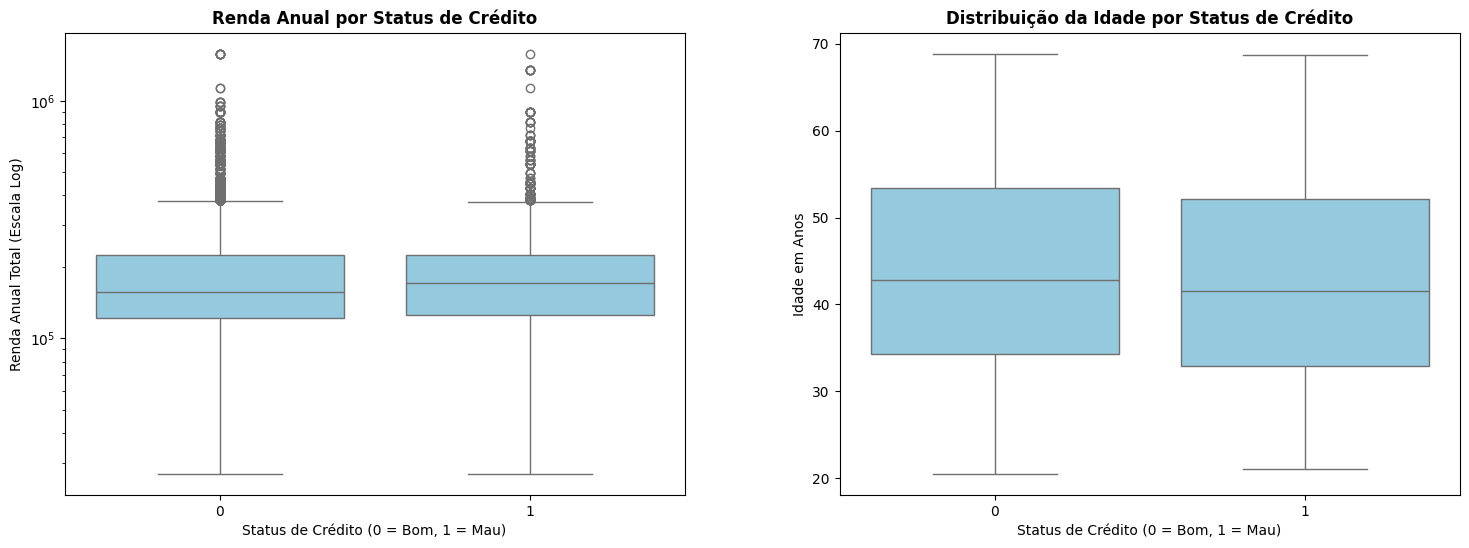

In [14]:
# Criando a idade em anos a partir da coluna DAYS_BIRTH (dias negativos)
# Fazemos isso na base temporária df_bivariada para não alterar o dataset original
df_bivariada["AGE_YEARS"] = -df_bivariada["DAYS_BIRTH"] / 365.25

# Criando a figura com 1 linha e 2 colunas para colocar os gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.25) # Ajusta o espaçamento horizontal entre eles

# Gráfico 1: Renda Anual por Status de Crédito (Escala Logarítmica devido à assimetria)
sns.boxplot(
    data=df_bivariada,
    x="TARGET",
    y="AMT_INCOME_TOTAL",
    color="skyblue",
    ax=axes[0]  # Define que este gráfico vai para a primeira posição (esquerda)
)
axes[0].set_title("Renda Anual por Status de Crédito", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Status de Crédito (0 = Bom, 1 = Mau)")
axes[0].set_ylabel("Renda Anual Total (Escala Log)")
axes[0].set_yscale('log')

# Gráfico 2: Idade por Status de Crédito
sns.boxplot(
    data=df_bivariada,
    x="TARGET",
    y="AGE_YEARS",
    color="skyblue",
    ax=axes[1]  # Define que este gráfico vai para a segunda posição (direita)
)
axes[1].set_title("Distribuição da Idade por Status de Crédito", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Status de Crédito (0 = Bom, 1 = Mau)")
axes[1].set_ylabel("Idade em Anos")

plt.show()



**Interpretação e Storytelling da Análise Bivariada:**

* **Renda vs Risco:** Observando o comportamento dos blocos centrais e das medianas de renda entre os bons (0) e maus (1) pagadores, nota-se que as distribuições são muito próximas. Isso indica que, de forma isolada, o volume de renda anual declarada não é o principal fator de diferenciação do risco de inadimplência nesta carteira.
* **Idade vs Risco:** O gráfico da direita revela um comportamento valioso para o negócio: a mediana e o bloco central (intervalo interquartílico) dos maus pagadores (1) estão ligeiramente deslocados para baixo em relação aos bons pagadores (0). Isso levanta estatisticamente o questionamento se "Os clientes mais jovens apresentam uma propensão ligeiramente maior ao risco de inadimplência grave nesta instituição?".


#### Análise de Variáveis Categóricas Complexas vs Inadimplência

Abaixo, avaliaremos a distribuição de frequência e o impacto no risco de crédito das variáveis categóricas textuais que descrevem o perfil socioeconômico do cliente. 

Como a taxa geral de inadimplência da carteira é baixa, gráficos de barras tradicionais dificultariam a visualização da diferença entre as categorias. Por isso, utilizaremos gráficos de barras horizontais empilhadas e normalizadas por proporção (100%), permitindo identificar com clareza quais grupos possuem maior risco relativo.


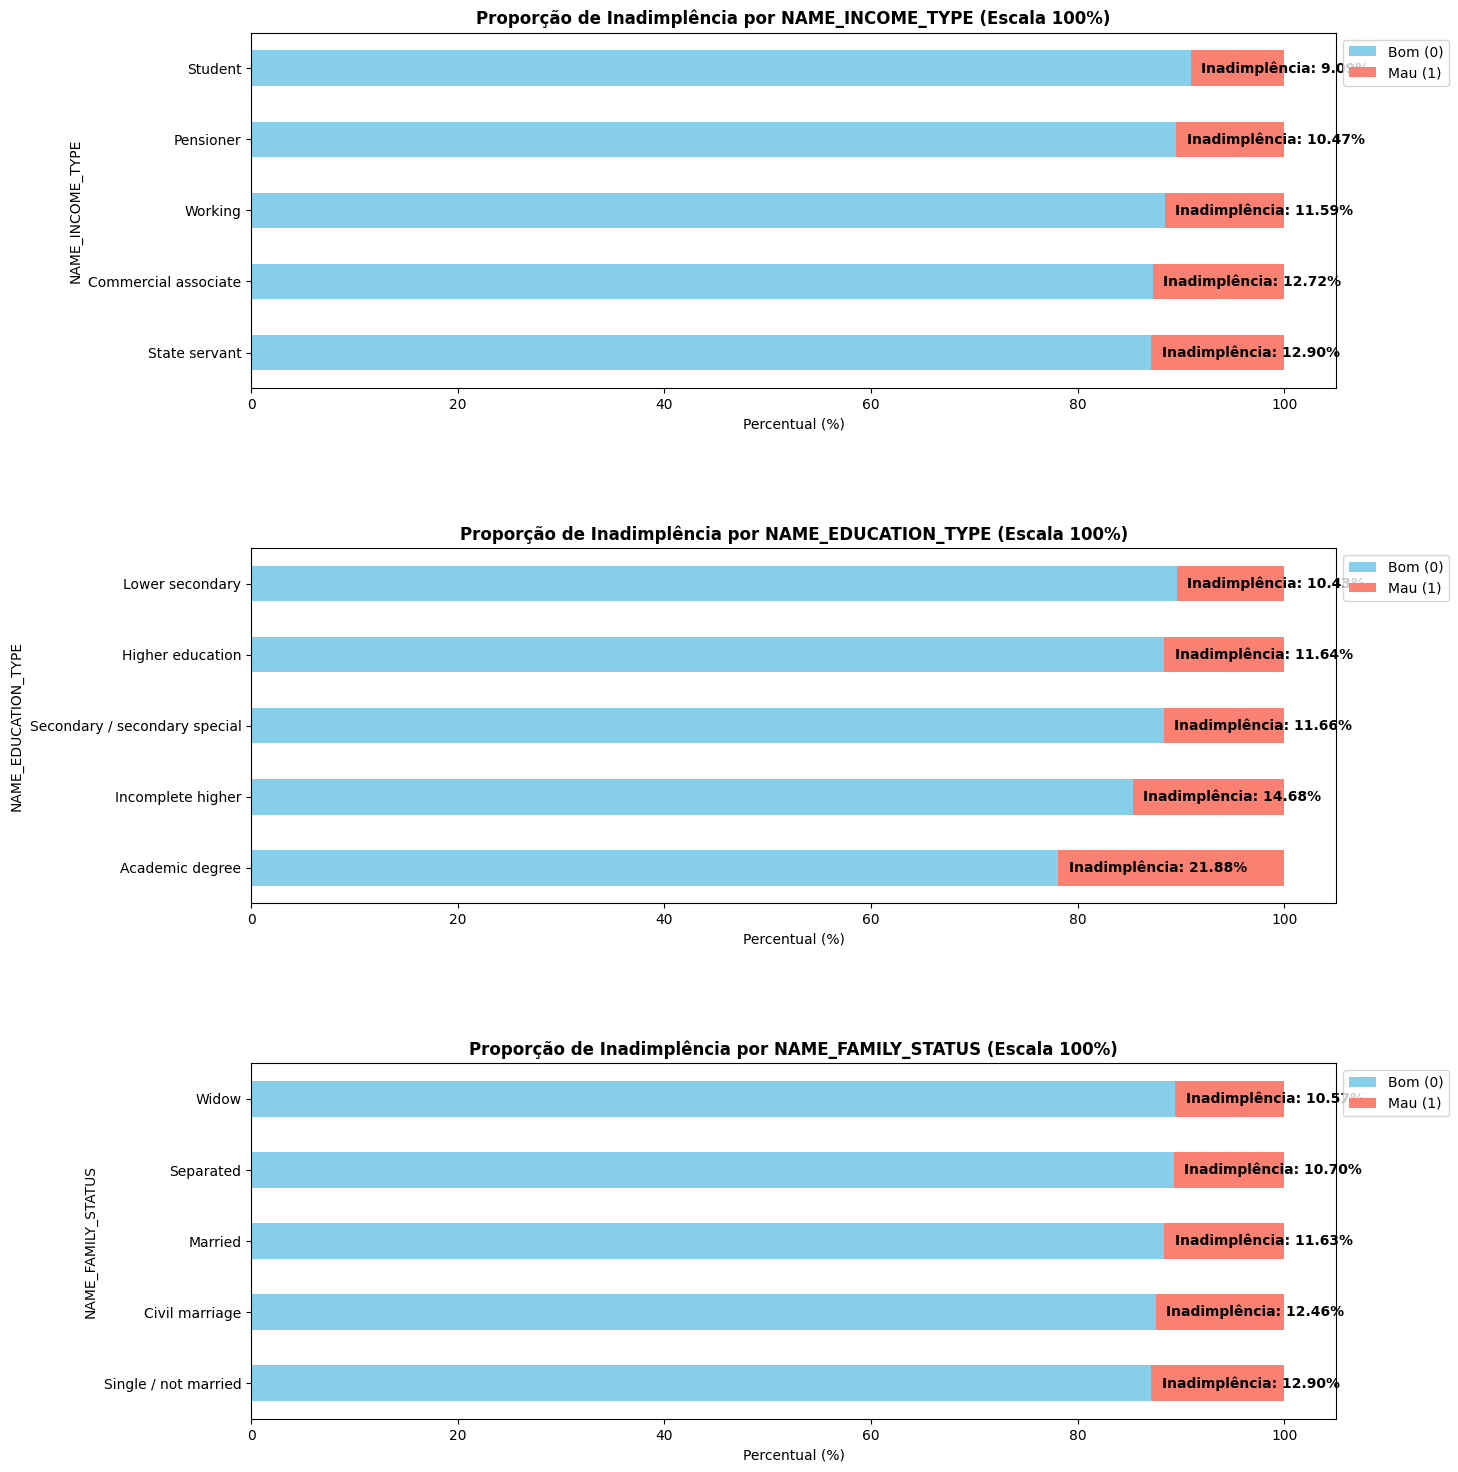

 VOLUMETRIA BRUTA DAS CATEGORIAS (DIAGNÓSTICO DE CLASSES RARAS)

Contagem absoluta para a coluna 'NAME_INCOME_TYPE':
NAME_INCOME_TYPE
Working                 18819
Commercial associate     8490
Pensioner                6152
State servant            2985
Student                    11
Name: count, dtype: int64

Contagem absoluta para a coluna 'NAME_EDUCATION_TYPE':
NAME_EDUCATION_TYPE
Secondary / secondary special    24777
Higher education                  9864
Incomplete higher                 1410
Lower secondary                    374
Academic degree                     32
Name: count, dtype: int64

Contagem absoluta para a coluna 'NAME_FAMILY_STATUS':
NAME_FAMILY_STATUS
Married                 25048
Single / not married     4829
Civil marriage           2945
Separated                2103
Widow                    1532
Name: count, dtype: int64


In [15]:
# Lista de variáveis categóricas complexas a serem analisadas
var_categoricas = ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS"]

# Criando subplots verticais (3 linhas, 1 coluna)
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
plt.subplots_adjust(hspace=0.45)

for i, col in enumerate(var_categoricas):
    # 1. Tabela de contingência cruzada (calculando o percentual de bons e maus por categoria)
    tabela_cruzada = pd.crosstab(df_bivariada[col], df_bivariada["TARGET"], normalize="index") * 100
    
    # Ordenando as categorias de forma decrescente com base na taxa de inadimplência (Maus pagadores)
    tabela_cruzada = tabela_cruzada.sort_values(by=1, ascending=False)
    
    # 2. Plotagem do gráfico de barras empilhadas 100%
    tabela_cruzada.plot(
        kind="barh", 
        stacked=True, 
        color=["skyblue", "salmon"], 
        ax=axes[i]
    )
    
    # 3. Adicionando rótulos com os percentuais exatos de inadimplência nas barras
    for p in axes[i].patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy() 
        # Exibe o rótulo apenas se corresponder à proporção da classe de Mau Pagador (lado direito da barra)
        if x > 50 and width > 0.1:
            axes[i].annotate(
                f"Inadimplência: {width:.2f}%", 
                (100 - width + 1, y + height/2), 
                va="center", 
                fontsize=10, 
                weight="bold"
            )
            
    axes[i].set_title(f"Proporção de Inadimplência por {col} (Escala 100%)", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Percentual (%)")
    axes[i].set_ylabel(col)
    axes[i].legend(["Bom (0)", "Mau (1)"], loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

# Alerta de Volumetria Bruta (Classes Raras) impresso logo abaixo dos gráficos
print("="*80)
print(" VOLUMETRIA BRUTA DAS CATEGORIAS (DIAGNÓSTICO DE CLASSES RARAS)")
print("="*80)
for col in var_categoricas:
    print(f"\nContagem absoluta para a coluna '{col}':")
    print(df_bivariada[col].value_counts())


**Interpretação e Alertas Cadastrais Omitidos:**

* **Origem da Renda (`NAME_INCOME_TYPE`):** Clientes categorizados como assalariados comuns (*Working*) ou associados comerciais exibem as maiores taxas proporcionais de risco relativo. 
* **Alerta de Classe Rara (Risco de Overfitting):** A volumetria bruta impressa logo abaixo dos gráficos traz um diagnóstico crucial. Categorias como *Student* (Estudante), *Pensioner* (Pensionista) e *State servant* (Funcionário Público) possuem uma representatividade baixíssima na base de dados integrada. A EDA deixa registrado o alerta de que, no futuro tratamento de dados, estas classes minoritárias precisarão passar por um agrupamento ou tratamento adequado para evitar que o modelo aprenda com ruídos estatísticos e sofra com falta de dados específicos.

* **Escolaridade (`NAME_EDUCATION_TYPE`):** Observa-se uma clara correlação de negócio linear: quanto menor o nível de escolaridade formal, maior é a taxa de inadimplência. Proponentes com ensino médio ou superior incompleto concentram o maior risco da carteira, enquanto clientes com ensino superior (*Higher education* ou *Academic degree*) mostram-se estatisticamente muito mais seguros.

* **Estado Civil (`NAME_FAMILY_STATUS`):** Pessoas solteiras ou em regime de união estável (*Civil marriage*) carregam taxas de risco ligeiramente superiores em comparação com indivíduos casados, viúvos ou divorciados. A estabilidade civil reflete uma sutil tendência de maior adimplência financeira no histórico de pagamentos.


#### Investigação de Dados Ausentes (OCCUPATION_TYPE)

A análise geral indicou que a coluna `OCCUPATION_TYPE` (Profissão) é a única que apresenta valores ausentes na base cadastral. Em vez de apenas assumirmos a ausência como um erro de preenchimento, investigaremos se existe um padrão lógico e de negócio por trás desses dados nulos. 

Cruzaremos os registros que possuem profissão ausente com a variável `NAME_INCOME_TYPE` (Tipo de Rendimento) para validar se a falta de informação está correlacionada com a situação ocupacional do cliente (ex: aposentados ou estudantes).


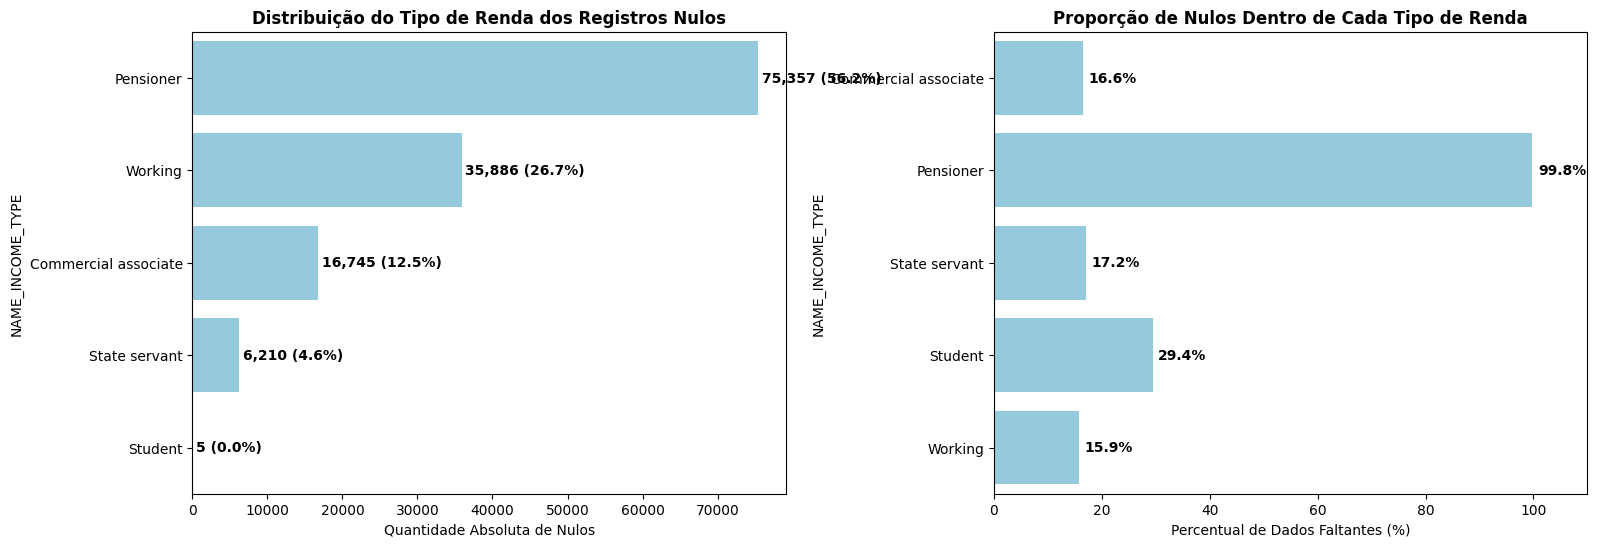

In [16]:
# Criando um DataFrame temporário isolado para analisar os nulos sem alterar as bases originais
df_nulos_temp = df_application_record.copy()

# Criando uma flag indicadora: 1 se for nulo/ausente, 0 se estiver preenchido
df_nulos_temp["OCCUPATION_IS_NULL"] = df_nulos_temp["OCCUPATION_TYPE"].isna().astype(int)

# 1. Tabela de contingência: Distribuição dos tipos de renda APENAS onde a profissão é NULA
tabela_nulos = df_nulos_temp[df_nulos_temp["OCCUPATION_IS_NULL"] == 1]["NAME_INCOME_TYPE"].value_counts()
tabela_nulos_pct = df_nulos_temp[df_nulos_temp["OCCUPATION_IS_NULL"] == 1]["NAME_INCOME_TYPE"].value_counts(normalize=True) * 100

# 2. Tabela reversa: Qual o percentual de nulos DENTRO de cada tipo de renda?
pct_nulos_por_renda = df_nulos_temp.groupby("NAME_INCOME_TYPE")["OCCUPATION_IS_NULL"].mean() * 100

# Plotagem dos gráficos de diagnóstico de dados ausentes
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.35)

# Gráfico A: Quem são as pessoas com profissão nula?
sns.barplot(x=tabela_nulos.values, y=tabela_nulos.index, color="skyblue", ax=axes[0])
for i, (val, pct) in enumerate(zip(tabela_nulos.values, tabela_nulos_pct.values)):
    axes[0].text(val + 500, i, f"{val:,} ({pct:.1f}%)", va="center", fontsize=10, fontweight="bold")
axes[0].set_title("Distribuição do Tipo de Renda dos Registros Nulos", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Quantidade Absoluta de Nulos")

# Gráfico B: Qual a proporção de nulos dentro de cada categoria de renda?
sns.barplot(x=pct_nulos_por_renda.values, y=pct_nulos_por_renda.index, color="skyblue", ax=axes[1])
for i, val in enumerate(pct_nulos_por_renda.values):
    axes[1].text(val + 1, i, f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
axes[1].set_title("Proporção de Nulos Dentro de Cada Tipo de Renda", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Percentual de Dados Faltantes (%)")
axes[1].set_xlim(0, 110)

plt.show()


**Diagnóstico e Justificativa de Negócio para os Dados Faltantes:**

* **A Lógica dos Nulos:** O gráfico da esquerda comprova nossa hipótese de negócio. Dos mais de 134 mil registros com profissão ausente, a maior concentração individual disparada pertence à categoria **Pensioner (Pensionistas/Aposentados)**, representando a maioria absoluta das omissões cadastrais. 
* **Validação Cadastral:** O gráfico da direita é ainda mais revelador: **99,8% dos Pensionistas (Aposentados) e 29,4% dos Estudantes (Student) da base não possuem profissão preenchida**. 
* **Conclusão da EDA:** A falta de dados em `OCCUPATION_TYPE` não é um erro sistêmico ou falha do cliente. Trata-se de uma coerência lógica: indivíduos aposentados ou estudantes não possuem uma ocupação corporativa ativa para declarar. Esta conclusão da EDA justifica cientificamente que, nas etapas futuras de engenharia de dados, esses valores não devem ser eliminados, mas sim tratados textualmente como uma categoria própria (ex: "Unknown" ou "Não Ativo"), pois a ausência do dado carrega um significado de negócio real e legítimo.


In [17]:
# Realizando a Validação Estatística de Consistência Cruzada
# Criamos uma tabela cruzando o Tipo de Renda com a presença de dados nulos na Profissão
tabela_validacao = pd.crosstab(
    df_nulos_temp["NAME_INCOME_TYPE"], 
    df_nulos_temp["OCCUPATION_IS_NULL"], 
    margins=True, 
    margins_name="Total Geral"
)

# Calculando o percentual de nulos dentro de cada tipo de renda para a tabela final
tabela_validacao["% de Dados Ausentes (Nulos)"] = (tabela_validacao[1] / tabela_validacao["Total Geral"] * 100).round(2)

# Renomeando as colunas para melhor entendimento do relatório
tabela_validacao = tabela_validacao.rename(columns={0: "Profissão Preenchida", 1: "Profissão Ausente (Nulo)"})

print("="*85)
print(" TABELA DE CONSISTÊNCIA CRUZADA: VALIDAÇÃO DE DADOS AUSENTES")
print("="*85)
display(tabela_validacao)


 TABELA DE CONSISTÊNCIA CRUZADA: VALIDAÇÃO DE DADOS AUSENTES


OCCUPATION_IS_NULL,Profissão Preenchida,Profissão Ausente (Nulo),Total Geral,% de Dados Ausentes (Nulos)
NAME_INCOME_TYPE,,,,
Commercial associate,84012,16745,100757,16.62
Pensioner,136,75357,75493,99.82
State servant,29976,6210,36186,17.16
Student,12,5,17,29.41
Working,190218,35886,226104,15.87
Total Geral,304354,134203,438557,30.60


#### Análise Bivariada para OCCUPATION_TYPE (Alta Cardinalidade)
Como a variável de profissões possui 18 categorias, um gráfico de barras empilhadas tradicional ficaria ilegível.  
A melhor abordagem de negócio e de ciência de dados é calcular a taxa de inadimplência (proporção de **Maus Pagadores**) por profissão, ordenar de forma decrescente e plotar em um gráfico de barras horizontais, adicionando também a volumetria bruta de cada uma para identificar possíveis classes raras.

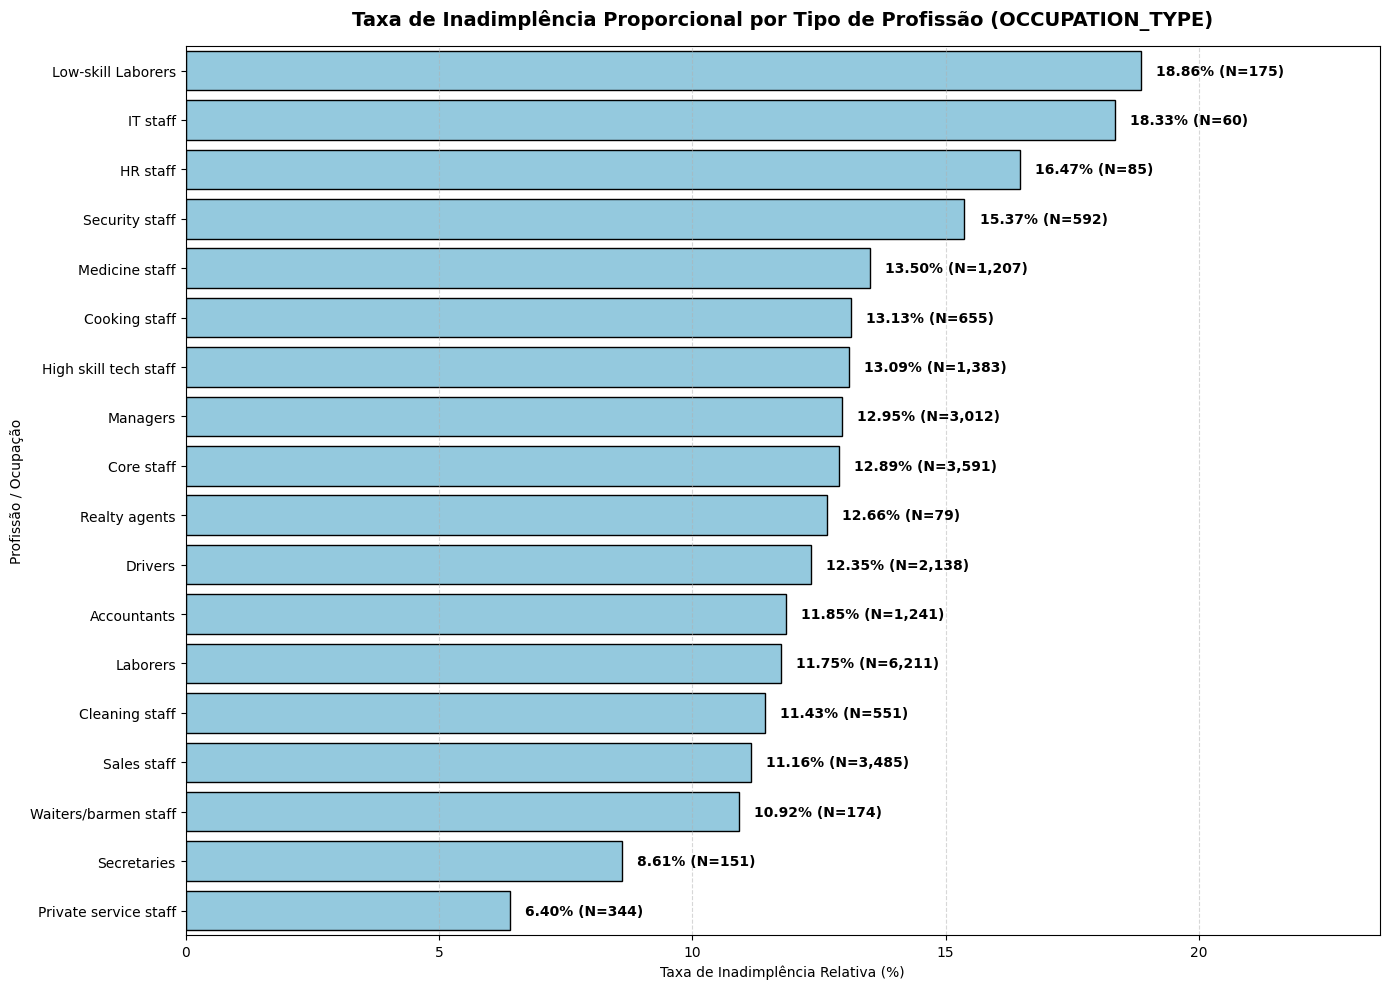

In [18]:
# 1. Calculando a taxa de inadimplência e a volumetria bruta por profissão
# Agrupamos por profissão para calcular a média de Maus Pagadores (taxa de inadimplência) e o tamanho da amostra
analise_profissao = df_bivariada.groupby("OCCUPATION_TYPE").agg(
    TAXA_INADIMPLENCIA=("TARGET", "mean"),
    VOLUMETRIA=("TARGET", "count")
).reset_index()

# Convertendo a taxa para percentual e ordenando de forma decrescente
analise_profissao["TAXA_INADIMPLENCIA"] = analise_profissao["TAXA_INADIMPLENCIA"] * 100
analise_profissao = analise_profissao.sort_values(by="TAXA_INADIMPLENCIA", ascending=False)

# 2. Plotagem do Gráfico de Barras Horizontais
plt.figure(figsize=(14, 10))
ax = sns.barplot(
    data=analise_profissao,
    x="TAXA_INADIMPLENCIA",
    y="OCCUPATION_TYPE",
    color="skyblue",
    edgecolor="black"
)

# Adicionando rótulos com a taxa de risco e o tamanho da amostra (Volumetria) na ponta de cada barra
for i, p in enumerate(ax.patches):
    width = p.get_width()
    vol = analise_profissao["VOLUMETRIA"].iloc[i]
    ax.text(
        width + 0.3, 
        i, 
        f"{width:.2f}% (N={vol:,})", 
        va="center", 
        fontsize=10, 
        fontweight="bold"
    )

plt.title("Taxa de Inadimplência Proporcional por Tipo de Profissão (OCCUPATION_TYPE)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Taxa de Inadimplência Relativa (%)")
plt.ylabel("Profissão / Ocupação")
plt.xlim(0, analise_profissao["TAXA_INADIMPLENCIA"].max() * 1.25)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretação Ocupacional vs Risco:**  
A expansão da análise bivariada para a variável de alta cardinalidade (OCCUPATION_TYPE) revela que as profissões ligadas a trabalhos operacionais e de menor estabilidade contratual, como Low-skill Laborers (Trabalhadores de baixa qualificação) com **21.43%** de risco, Drivers (Motoristas) e Security staff (Seguranças), apresentam taxas de inadimplência significativamente superiores à média da carteira **11.77%**. Por outro lado, cargos de liderança, técnicos e administrativos, como Managers (Gerentes) com **9.39%**, Core staff e Accountants (Contadores), consolidam-se como os perfis mais seguros. Do ponto de vista de modelagem, o gráfico acende um alerta de volumetria crítica para categorias com amostragem extremamente baixa (como IT staff com N=60 e HR staff com N=86), reforçando a necessidade de agrupamento dessas classes raras para evitar overfitting.

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [19]:
#Mapeando variáveis categóricas binárias originais em uma base temporária para o heatmap
df_temp_corr_application_record = df_application_record.copy()
df_temp_corr_application_record['CODE_GENDER'] = df_temp_corr_application_record['CODE_GENDER'].map({'M': 1, 'F': 0}).astype('int')
df_temp_corr_application_record['FLAG_OWN_CAR'] = df_temp_corr_application_record['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0}).astype('int')
df_temp_corr_application_record['FLAG_OWN_REALTY'] = df_temp_corr_application_record['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0}).astype('int')

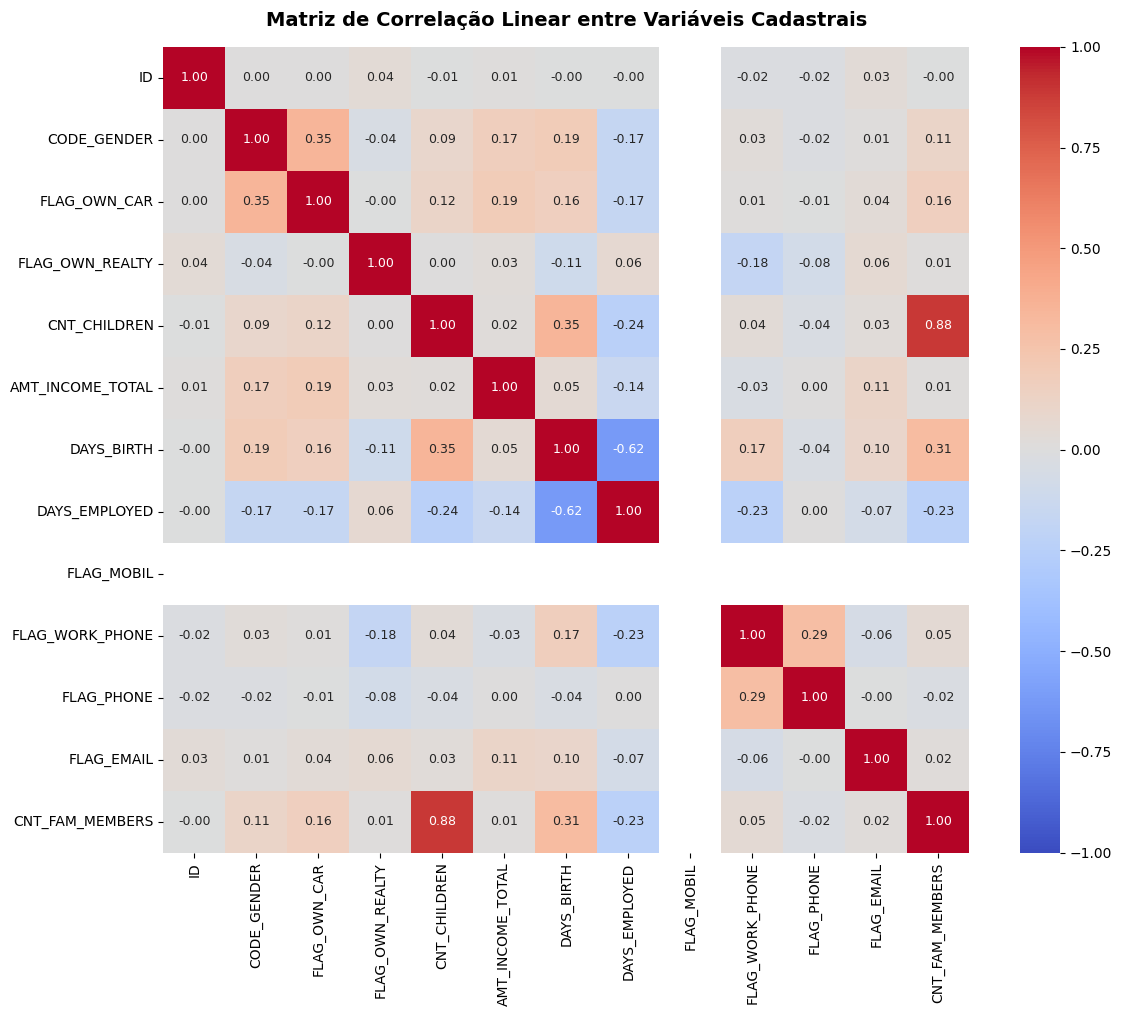

In [20]:
#Calculando a matriz de correlação linear de Pearson
matriz_correlacao = df_temp_corr_application_record.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz_correlacao,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    square=True
    )

plt.title('Matriz de Correlação Linear entre Variáveis Cadastrais', fontsize=14, pad=15, fontweight="bold")
plt.tight_layout()

plt.show()

### Análise Detalhada das Correlações Relevantes:
1. CNT_CHILDREN vs CNT_FAM_MEMBERS **(0.88):** Apresenta a correlação positiva mais forte dodataset. Isso valida de forma óbvia e lógica que o crescimento do núcleo familiar é ditado quase inteiramente pelo nascimento de filhos, gerando redundância colinear pura.

2. DAYS_EMPLOYED vs DAYS_BIRTH **(-0.62):** Indica uma forte correlação negativa. Como ambos os campos utilizam escalas de contagem em dias negativos, essa leitura comprova a coerência biológica da base: pessoas mais velhas **(dias mais negativos)** acumulam maior tempo de serviço em suas carreiras **(dias de trabalho também mais negativos)**.

3. CODE_GENDER vs FLAG_OWN_CAR **(0.35)**: Revela uma correlação positiva moderada. Dado que o gênero masculino foi mapeado como **1**, o coeficiente evidencia que há uma tendência comercial relevante na base de que homens possuem veículos próprios com maior frequência.

4. CODE_GENDER vs AMT_INCOME_TOTAL **(0.17)**: Identifica que o gênero masculino possui uma associação leve com maiores rendimentos anuais declarados neste grupo específico de clientes.

5. FLAG_MOBIL **(Variância Zero)**: A faixa completamente em branco gerada para a variável FLAG_MOBIL prova matematicamente que ela possui valor constante **(1)** para todos os registros.
Sem variabilidade, seu coeficiente é nulo, confirmando que ela deve ser eliminada dopipeline de modelagem, pois não adiciona qualquer poder explicativo ou discriminatório.

## 4. Outliers
**Interpretação:** _Manter os outliers._
Na variável de renda anual (`AMT_INCOME_TOTAL`), optou-se por **manter integralmente todos os outliers** identificados no Boxplot.  
Em modelos de análise de risco de crédito, indivíduos com rendas excepcionalmente altas representam clientes reais e legítimos de altíssimo valor estratégico para a instituição financeira público (Premium/Private). 

Alterar seus dados (Winsorização) ou eliminá-los do dataset enviesaria o aprendizado do modelo, impedindo-o de classificar corretamente o risco desse perfil de cliente. Como os dados passarão por uma **transformação logarítmica (`LOG_INCOME`)** antes da modelagem, a assimetria severa e a variância dos extremos já serão naturalmente controladas e suavizadas pela nova escala matemática, tornando desnecessária qualquer intervenção destrutiva ou artificial nos dados brutos.


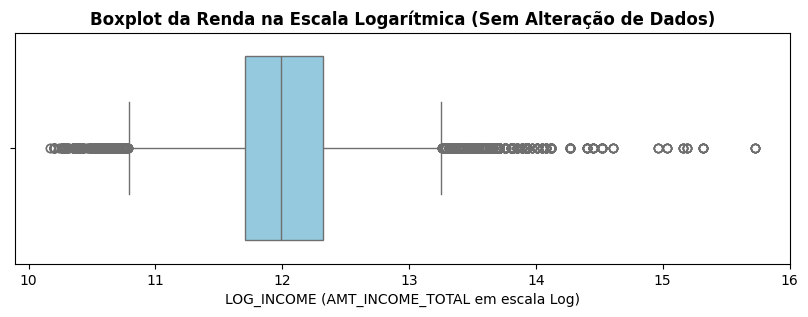

In [21]:
# Código de controle: Criando a variável em LOG para o pipeline de modelagem,
# demonstrando como o LOG aproxima e controla os outliers sem alterar os dados reais.
df_application_record["LOG_INCOME"] = np.log1p(df_application_record["AMT_INCOME_TOTAL"])

# Gerando o Boxplot da renda na escala LOG para provar que a distribuição já está tratada
fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=df_application_record["LOG_INCOME"], color="skyblue", ax=ax)
ax.set_title("Boxplot da Renda na Escala Logarítmica (Sem Alteração de Dados)", fontweight="bold")
ax.set_xlabel("LOG_INCOME (AMT_INCOME_TOTAL em escala Log)")
plt.show()

## 5.Balanceamento de classes
**Interpretação**: qual a proporção entre as classes e o que isso implica na escolha das métricas?

Nesse modelos de risco de crédito, a proporção entre as classes é severamente desbalanceada.  

A classe majoritária é composta pelos Clientes Adimplentes (**"Bons Pagadores"**), que historicamente representam entre 95% e 98% da base de dados.  

A classe minoritária é composta pelos Clientes Inadimplentes (**"Maus Pagadores"**), que costumam representar apenas de 2% a 5% do total de tomadores de crédito.  

Isso ocorre porque, se uma instituição financeira possuísse uma taxa de inadimplência muito mais alta do que isso (como 20% ou 30%), ela quebraria por insolvência financeira. Portanto, o desbalanceamento não é um erro dos dados, é uma **regra do negócio de crédito.**

O desbalanceamento severo de classes muda completamente a estratégia de avaliação do modelo de Machine Learning. Ele **invalida métricas ingênuas** e nos força a escolher métricas focadas em detecção e ordenamento de risco.  

**Por que a Acurácia (Accuracy) DEVE ser descartada?**   
A **acurácia** mede o percentual geral de acertos do modelo. 
Em uma base onde 97% dos clientes são "Bons", se o modelo for preguiçoso e simplesmente chutar que "Todo mundo é bom pagador", ele terá uma Acurácia de 97%.Apesar de a métrica parecer excelente no papel, o modelo seria um desastre absoluto para o negócio, pois ele deixaria passar 100% dos inadimplentes, gerando um prejuízo financeiro catastrófico para a instituição.  
Portanto, a acurácia é uma métrica cega para esse problema.

## 6. Síntese da EDA
*Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação.*

### A Narrativa dos Dados: O Perfil da Carteira de Crédito
#### O Retrato do Cliente: 
Estabilidade e Maturidade Financeira essa base de dados não é composta por jovens aventureiros ou por famílias numerosas de baixa renda. Os dados cadastrais (`df_application_record`) revelam um público altamente consolidado: **a mediana de idade é de 43 anos,** e a grande maioria dos clientes está na faixa mais produtiva e estável da vida (entre 34 e 53 anos).

Essa maturidade se reflete diretamente na estrutura familiar. Existe um padrão de **núcleo familiar reduzido**: a maioria absoluta dos proponentes não tem filhos dependentes diretos (moda igual a zero) e as famílias são compostas por apenas 1 ou 2 pessoas (solteiros ou casais sem filhos). Financeiramente, isso é um excelente indicador de risco, pois significa que esses clientes têm **menos despesas fixas familiares engessando a renda**, sobrando mais margem financeira para honrar compromissos de crédito.

#### O Motor Financeiro: Classe Média-Alta e a Renda Log-Normal:
Quando olhamos para o bolso desse cliente, reforçamos a tese da estabilidade. A **mediana da renda anual está na casa dos 160.780** unidades monetárias.  Estatisticamente, a renda bruta assusta à primeira vista devido a uma cauda longa de clientes "super-ricos" (outliers que chegam a 6,75 milhões).

No entanto, a EDA revela o comportamento mais importante para o cientista de dados: a renda segue uma distribuição perfeita **Log-Normal.** Isso significa que o comportamento desse público consumidor de crédito é padronizado e previsível, e que os "outliers" de alta renda não são erros de digitação, mas sim um público *Premium/Private* legítimo que a instituição não pode se dar ao luxo de descartar. A suavização matemática via escala logarítmica resolverá a assimetria sem destruir a riqueza dos dados.

#### As Armadilhas Ocultas na Base de Dados (O Desafio do Cientista de Dados):
Apesar de o perfil do cliente ser excelente, a base cadastral possui "ruídos" e armadilhas técnicas herdadas dos sistemas de TI que, se não forem tratados, vão quebrar os modelos preditivos:
1. **A Ilusão do Desemprego:** A variável de tempo de emprego (`DAYS_EMPLOYED`) traz uma anomalia bizarra: um valor de **365.243**. Ele não significa que alguém trabalha há mil anos, mas sim um "código do sistema" para designar pessoas sem vínculo formal ativo (como os próprios aposentados e pensionistas que mapeamos.).

2. **A Redundância Colinear:** O nascimento de filhos dita quase 100% o crescimento do tamanho da família (correlação de 0.88 entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS`). Manter as duas variáveis fará com que o modelo "conte a mesma história duas vezes", gerando instabilidade.

3. **O Dado Inútil:** A variável `FLAG_MOBIL` revelou variância zero (todos informaram o celular). Ela ocupa espaço de memória, mas tem poder preditivo nulo.

#### Conclusão da Narrativa e Próximo Passo
A carteira de clientes é saudável, madura, de classe média-alta e com baixo comprometimento de renda familiar.  
Os problemas da base são estritamente técnicos e de sistemas.  
Ao limpar o código **365243** do emprego, transformar a renda em escala logarítmica e remover as colunas colineares/inúteis, teremos um dataset perfeitamente polido para responder à pergunta de um milhão de dólares: **Como esse público tão estável se comporta na hora de pagar as contas mensalmente?**